[*********************100%***********************]  1 of 1 completed

Sharpe Ratio: 0.6326


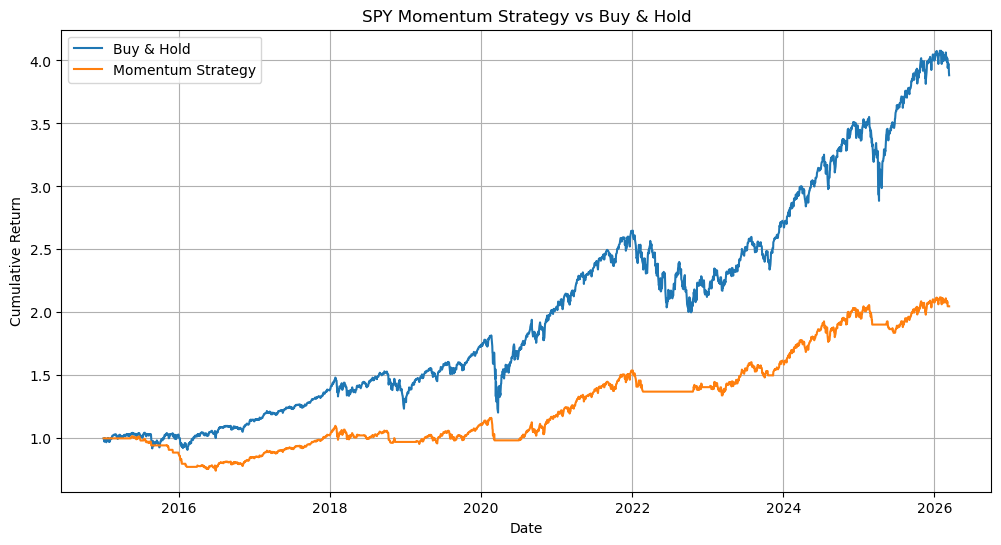

,close,daily_return,momentum_90d,signal,strategy_return,buy_hold_cum,strategy_cum
Date,,,,,,,
2026-03-09,678.270020,0.008760,-0.007247,0,0.0,3.976034,2.048198
2026-03-10,677.179993,-0.001607,-0.011468,0,-0.0,3.969644,2.048198
2026-03-11,676.330017,-0.001255,-0.013182,0,-0.0,3.964662,2.048198
2026-03-12,666.059998,-0.015185,-0.017360,0,-0.0,3.904459,2.048198
2026-03-13,662.289978,-0.005660,-0.026117,0,-0.0,3.882359,2.048198


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download SPY data
data = yf.download("SPY", start="2015-01-01", auto_adjust=True)

# 2. Keep only close price
data = data[["Close"]].copy()
data.columns = ["close"]

# 3. Calculate daily return
data["daily_return"] = data["close"].pct_change()

# 4. Calculate 90-day momentum
data["momentum_90d"] = data["close"].pct_change(90)

# 5. Generate trading signal
# If momentum > 0, hold SPY; otherwise stay in cash
data["signal"] = np.where(data["momentum_90d"] > 0, 1, 0)

# 6. Strategy return
# Use yesterday's signal to avoid look-ahead bias
data["strategy_return"] = data["signal"].shift(1) * data["daily_return"]

# 7. Buy-and-hold cumulative return
data["buy_hold_cum"] = (1 + data["daily_return"].fillna(0)).cumprod()

# 8. Strategy cumulative return
data["strategy_cum"] = (1 + data["strategy_return"].fillna(0)).cumprod()

# 9. Sharpe ratio
strategy_mean = data["strategy_return"].mean()
strategy_std = data["strategy_return"].std()
sharpe_ratio = (strategy_mean / strategy_std) * np.sqrt(252)

print("Sharpe Ratio:", round(sharpe_ratio, 4))

# 10. Plot
plt.figure(figsize=(12, 6))
plt.plot(data.index, data["buy_hold_cum"], label="Buy & Hold")
plt.plot(data.index, data["strategy_cum"], label="Momentum Strategy")
plt.title("SPY Momentum Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

# 11. Display last few rows
data.tail()